# Initial Data Analysis: PubHealth Dataset

The **PubHealth** dataset is designed for automated fact-checking of public health claims. It contains claims labeled into 4 classes: `true`, `false`, `mixture`, and `unproven`.

In this notebook, we perform an initial analysis of the dataset, including label distribution, text characteristics, and data quality check.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# Setting a basic style for matplotlib
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = False

## Load Data

In [2]:
data_path = "../../data/pubhealth"
train_df = pd.read_csv(os.path.join(data_path, "train.tsv"), sep="\t")
dev_df = pd.read_csv(os.path.join(data_path, "dev.tsv"), sep="\t")
test_df = pd.read_csv(os.path.join(data_path, "test.tsv"), sep="\t")

print(f"Train size: {len(train_df)}")
print(f"Dev size: {len(dev_df)}")
print(f"Test size: {len(test_df)}")

Train size: 9832
Dev size: 1221
Test size: 1235


## Label Distribution & Class Imbalance Analysis

In [3]:
valid_labels = ['true', 'false', 'mixture', 'unproven']

def get_label_stats(df, name):
    counts = df['label'].value_counts()
    print(f"--- {name} ---")
    for label, count in counts.items():
        percentage = (count / len(df)) * 100
        print(f"{label:10}: {count:5} ({percentage:5.2f}%)")
    print("")
    return counts

train_counts = get_label_stats(train_df, "Train")
dev_counts = get_label_stats(dev_df, "Dev")
test_counts = get_label_stats(test_df, "Test")

--- Train ---
true      :  5078 (51.65%)
false     :  3001 (30.52%)
mixture   :  1434 (14.59%)
unproven  :   291 ( 2.96%)
snopes    :     1 ( 0.01%)

--- Dev ---
true      :   629 (51.52%)
false     :   380 (31.12%)
mixture   :   164 (13.43%)
unproven  :    41 ( 3.36%)
National, Candidate Biography, Donald Trump, :     1 ( 0.08%)

--- Test ---
true      :   599 (48.50%)
false     :   388 (31.42%)
mixture   :   201 (16.28%)
unproven  :    45 ( 3.64%)



### Plotting Class Imbalance (Training Set)

Visualizing the distribution of labels in the training set with explicit counts above each bar.

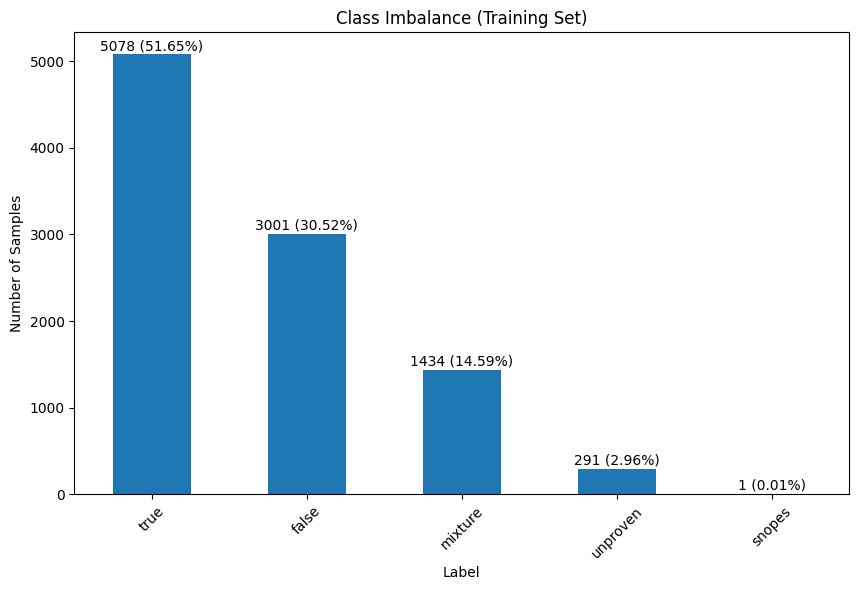

In [4]:
plt.figure(figsize=(10, 6))
ax = train_counts.plot(kind='bar')
plt.title("Class Imbalance (Training Set)")
plt.ylabel("Number of Samples")
plt.xlabel("Label")
plt.xticks(rotation=45)

# Add count and percentage above bars
total = len(train_df)
for i, v in enumerate(train_counts):
    pct = (v / total) * 100
    ax.text(i, v + 50, f"{v} ({pct:.2f}%)", ha='center')

plt.show()

### Cross-Split Class Distribution

Comparing the distribution of the 4 valid labels across Train, Dev, and Test splits.

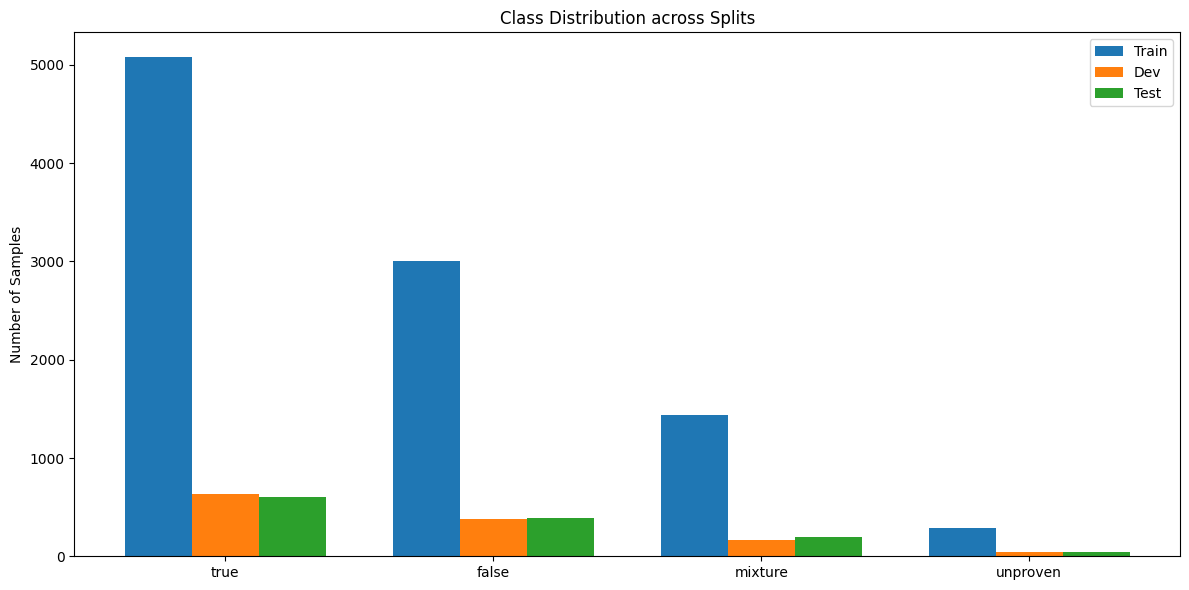

In [5]:
# Filter for the 4 main classes for comparison
train_clean = train_df[train_df['label'].isin(valid_labels)].copy()
dev_clean = dev_df[dev_df['label'].isin(valid_labels)].copy()
test_clean = test_df[test_df['label'].isin(valid_labels)].copy()

labels = valid_labels
train_vals = [train_clean[train_clean['label'] == l].shape[0] for l in labels]
dev_vals = [dev_clean[dev_clean['label'] == l].shape[0] for l in labels]
test_vals = [test_clean[test_clean['label'] == l].shape[0] for l in labels]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, train_vals, width, label='Train')
ax.bar(x, dev_vals, width, label='Dev')
ax.bar(x + width, test_vals, width, label='Test')

ax.set_ylabel('Number of Samples')
ax.set_title('Class Distribution across Splits')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()

## Data Inspection & Examples

Viewing specific examples for each class.

In [6]:
print("--- Examples per Class ---")
for label in valid_labels:
    example = train_clean[train_clean['label'] == label].iloc[0]
    print(f"Label: {label.upper()}")
    print(f"Claim: {example['claim']}")
    print(f"Explanation: {example['explanation'][:250]}...")
    print("-" * 50)

--- Examples per Class ---
Label: TRUE
Claim: Study: Vaccine for Breast, Ovarian Cancer Has Potential
Explanation: While the story does many things well, the overall framing of the story is that the vaccine “shows promise,” when the evidence actually points in the other direction. Because only one patient in the study remains cancer free and because that patient ...
--------------------------------------------------
Label: FALSE
Claim: "The money the Clinton Foundation took from from foreign governments while Hillary Clinton was secretary of state ""is clearly illegal. … The Constitution says you can’t take this stuff."
Explanation: "Gingrich said the Clinton Foundation ""took money from from foreign governments while (Hillary Clinton) was secretary of state. It is clearly illegal. … The Constitution says you can’t take this stuff."" A clause in the Constitution does prohibit U....
--------------------------------------------------
Label: MIXTURE
Claim: Annual Mammograms May Have More 

## Text Analysis

Checking the word count distribution for claims and explanations.

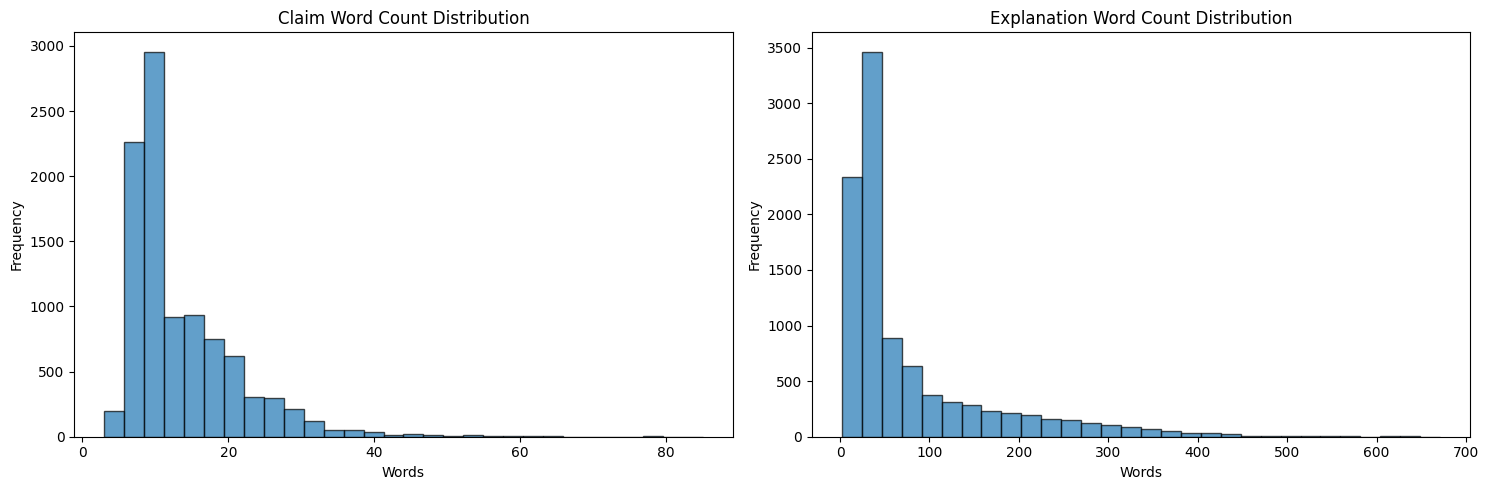

In [7]:
train_clean['claim_len'] = train_clean['claim'].str.split().str.len()
train_clean['explanation_len'] = train_clean['explanation'].astype(str).str.split().str.len()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(train_clean['claim_len'], bins=30, edgecolor='black', alpha=0.7)
ax1.set_title("Claim Word Count Distribution")
ax1.set_xlabel("Words")
ax1.set_ylabel("Frequency")

ax2.hist(train_clean['explanation_len'], bins=30, edgecolor='black', alpha=0.7)
ax2.set_title("Explanation Word Count Distribution")
ax2.set_xlabel("Words")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Metric: Macro-F1

The primary metric is **Macro-F1**. This calculates the F1 score for each class independently and then takes the average, giving equal weight to each class regardless of its size. This is crucial for handling the class imbalance observed above.

In [8]:
from sklearn.metrics import f1_score

# Baseline: always predict the majority class ('true')
y_true = test_clean['label']
y_pred = ["true"] * len(y_true)

print(f"Baseline Macro-F1 (always 'true'): {f1_score(y_true, y_pred, average='macro'):.4f}")

Baseline Macro-F1 (always 'true'): 0.1635
